# Week 06 · Wednesday — First ML Pipeline
**Baselines, Linear & Logistic Regression, and Metrics That Don't Lie**

**Learning objectives:**
- Correct train/test split (no data leakage)
- Build and evaluate a dumbest-possible baseline
- One-hot encode a categorical column
- Train Linear Regression → interpret RMSE & R²
- Train Logistic Regression → interpret accuracy, precision, recall, F1
- Assemble a single reproducible, seed-fixed pipeline

## 1. Imports

In [1]:
import numpy as np
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.dummy import DummyRegressor, DummyClassifier
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import (
    mean_squared_error,
    r2_score,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    ConfusionMatrixDisplay
)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

In [2]:
Path("Data").mkdir(parents=True, exist_ok=True)
Path("Graph").mkdir(parents=True, exist_ok=True)

## 2. Regenerate the students dataset (`seed=21`, `n=600`)

Same dataset used on Monday: `study_hours_per_week`, `sleep_hours_per_night`,
`attendance_pct`, `class_section` (A/B/C), and the target `exam_score`.

In [3]:
rng = np.random.default_rng(seed=21)
n = 600

class_section = rng.choice(["A", "B", "C"], size=n, p=[0.34, 0.33, 0.33])
study_hours = rng.normal(10, 3.5, size=n).clip(0, None).round(1)
sleep_hours = rng.normal(7, 1.2, size=n).clip(3, 10).round(1)
attendance_pct = rng.normal(85, 10, size=n).clip(40, 100).round(1)

noise = rng.normal(0, 8, size=n)
section_bonus = pd.Series(class_section).map({"A": 0, "B": 0, "C": 4}).values
exam_score = (50 + 2.6*study_hours + 0.15*attendance_pct + section_bonus + noise).clip(0, 100).round(1)

students = pd.DataFrame({
    "student_id": np.arange(1, n + 1),
    "class_section": class_section,
    "study_hours_per_week": study_hours,
    "sleep_hours_per_night": sleep_hours,
    "attendance_pct": attendance_pct,
    "exam_score": exam_score,
})


students.to_csv("Data/raw_students.csv", index=False)

### Diagnosis

In [4]:
print("--- Basic Statistics ---")
students.head()

--- Basic Statistics ---


,student_id,class_section,study_hours_per_week,sleep_hours_per_night,attendance_pct,exam_score
0,1,C,11.0,7.3,89.4,100.0
1,2,B,9.1,7.7,72.4,72.2
2,3,C,2.2,8.5,84.6,67.2
3,4,A,13.5,7.5,83.4,100.0
4,5,B,11.0,5.4,100.0,100.0


In [5]:
students.describe(include="all")

,student_id,class_section,study_hours_per_week,sleep_hours_per_night,attendance_pct,exam_score
count,600.000000,600,600.000000,600.000000,600.000000,600.000000
unique,NaN,3,NaN,NaN,NaN,NaN
top,NaN,A,NaN,NaN,NaN,NaN
freq,NaN,212,NaN,NaN,NaN,NaN
mean,300.500000,NaN,10.089333,7.046000,85.583000,88.605000
std,173.349358,NaN,3.407213,1.122787,9.137597,10.205279
min,1.000000,NaN,0.400000,3.400000,62.000000,58.900000
25%,150.750000,NaN,7.700000,6.275000,78.900000,81.750000
50%,300.500000,NaN,10.000000,7.100000,85.700000,90.200000
75%,450.250000,NaN,12.500000,7.800000,92.325000,98.700000


In [6]:
students.shape

(600, 6)

In [7]:
students.info()

<class 'pandas.DataFrame'>
RangeIndex: 600 entries, 0 to 599
Data columns (total 6 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   student_id             600 non-null    int64  
 1   class_section          600 non-null    str    
 2   study_hours_per_week   600 non-null    float64
 3   sleep_hours_per_night  600 non-null    float64
 4   attendance_pct         600 non-null    float64
 5   exam_score             600 non-null    float64
dtypes: float64(4), int64(1), str(1)
memory usage: 28.3 KB


In [8]:
print("Students ------- Missing Values")
students.isna().sum()

Students ------- Missing Values


student_id               0
class_section            0
study_hours_per_week     0
sleep_hours_per_night    0
attendance_pct           0
exam_score               0
dtype: int64

In [9]:
students.duplicated().sum()

np.int64(0)

In [10]:
students["class_section"].value_counts()

class_section
A    212
B    198
C    190
Name: count, dtype: int64

## 3. Feature engineering — one-hot encode `class_section`

`pd.get_dummies(..., drop_first=True)`: if a row isn't Section B and isn't Section C,
it must be Section A — so a third column for A would be pure redundancy.


**Why?** Linear/Logistic Regression requires numerical inputs.
`class_section` holds strings ("A"/"B"/"C") — no arithmetic can be
performed on them directly.

`pd.get_dummies(..., drop_first=True)` creates binary (0/1) columns for
each category **except the first** (which becomes the implicit reference).
If a row is not Section B and not Section C, it must be Section A,
keeping a third "Section A" column would be pure redundancy that can
destabilise the model's mathematics (perfect multicollinearity).

In [11]:
features_df = pd.get_dummies(students,columns=["class_section"], drop_first=True, dtype=int)
feature_cols = [
    "study_hours_per_week",
    "sleep_hours_per_night",
    "attendance_pct",
] + [c for c in features_df.columns if c.startswith("class_section_")]

X = features_df[feature_cols]
y = features_df["exam_score"]

print("Feature columns:", feature_cols)
X.head()

Feature columns: ['study_hours_per_week', 'sleep_hours_per_night', 'attendance_pct', 'class_section_B', 'class_section_C']


,study_hours_per_week,sleep_hours_per_night,attendance_pct,class_section_B,class_section_C
0,11.0,7.3,89.4,0,1
1,9.1,7.7,72.4,1,0
2,2.2,8.5,84.6,0,1
3,13.5,7.5,83.4,0,0
4,11.0,5.4,100.0,1,0


## 4. Split once, with a fixed seed

Every model built today for the *regression* task uses this exact same split,
comparing a baseline and a real model on different data would make the comparison
meaningless.

In [12]:
X_train, X_test, y_train_reg, y_test_reg = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE
)

print("Train:", X_train.shape, " Test:", X_test.shape)
print(f"Training set : {X_train.shape[0]} rows")
print(f"Test set     : {X_test.shape[0]} rows")
print(f"Split ratio  : {X_test.shape[0]/len(X):.0%} test")

Train: (480, 5)  Test: (120, 5)
Training set : 480 rows
Test set     : 120 rows
Split ratio  : 20% test


## 5. Regression baseline — Part A: `DummyRegressor(strategy="mean")`

Predicts the training set's mean `exam_score` for every single row, regardless of
input. This is the score any real model has to beat before its number means anything.

`DummyRegressor(strategy="mean")` predicts the **training-set mean** for
every single row, regardless of any feature values.

**Why build this first?**
Any real model that can't beat a model that ignores all input features
has learned nothing useful. The baseline RMSE and R² set the floor.

In [13]:
dummy_reg = DummyRegressor(strategy="mean")
dummy_reg.fit(X_train, y_train_reg)

y_pred_dummy_reg = dummy_reg.predict(X_test)

dummy_rmse = np.sqrt(mean_squared_error(y_test_reg, y_pred_dummy_reg))
dummy_r2   = r2_score(y_test_reg, y_pred_dummy_reg)

print("=== Regression Baseline (DummyRegressor — predict mean) ===")
print(f"  RMSE : {dummy_rmse:.4f}")
print(f"  R²   : {dummy_r2:.4f}")
print(f"\n  Baseline always predicts exam_score = {dummy_reg.constant_.item():.2f}")
print(
    "\n  Interpretation: RMSE ≈ {:.1f} pts — predictions are off by ~{:.1f} "
    "exam points on average. R² = {:.4f} means the baseline performs slightly worse than using the test-set mean as the reference prediction." 
    "This is expected because the baseline uses the training-set mean.".format(
        dummy_rmse, dummy_rmse, dummy_r2
    )
)

=== Regression Baseline (DummyRegressor — predict mean) ===
  RMSE : 10.2978
  R²   : -0.0096

  Baseline always predicts exam_score = 88.40

  Interpretation: RMSE ≈ 10.3 pts — predictions are off by ~10.3 exam points on average. R² = -0.0096 means the baseline performs slightly worse than using the test-set mean as the reference prediction.This is expected because the baseline uses the training-set mean.


---
## 6. Regression — Part B: Linear Regression

`LinearRegression` finds coefficients that minimise the sum of squared
residuals across the training set, the same "least squares" idea as a
trend line on a scatter plot, extended to five features at once.

In [14]:
lin_reg = LinearRegression()
lin_reg.fit(X_train, y_train_reg)

y_pred_lin = lin_reg.predict(X_test)

lin_rmse = np.sqrt(mean_squared_error(y_test_reg, y_pred_lin))
lin_r2   = r2_score(y_test_reg, y_pred_lin)

print("=== Linear Regression ===")
print(f"  RMSE : {lin_rmse:.4f}")
print(f"  R²   : {lin_r2:.4f}")

rmse_improvement = dummy_rmse - lin_rmse
r2_improvement   = lin_r2 - dummy_r2

print(f"\n  Improvement over baseline:")
print(f"    RMSE reduced by {rmse_improvement:.4f} points")
print(f"    R² increased by {r2_improvement:.4f}")
print(
    f"\n  One-sentence summary: Linear Regression cut RMSE from "
    f"{dummy_rmse:.2f} to {lin_rmse:.2f} exam points (−{rmse_improvement:.2f}) "
    f"and lifted R² from ~0 to {lin_r2:.4f}, meaning the model now explains "
    f"{lin_r2*100:.1f}% of the variance in exam scores."
)

=== Linear Regression ===
  RMSE : 7.0584
  R²   : 0.5257

  Improvement over baseline:
    RMSE reduced by 3.2394 points
    R² increased by 0.5353

  One-sentence summary: Linear Regression cut RMSE from 10.30 to 7.06 exam points (−3.24) and lifted R² from ~0 to 0.5257, meaning the model now explains 52.6% of the variance in exam scores.


---
## 7. Regression — Part C: Coefficient Inspection
`model.coef_` next to the feature names. Compare this to whatever correlations
found against `exam_score`, the sign and rough ranking should agree,
since both are reading the same linear relationship in the data.


In [15]:
coef_df = pd.DataFrame({
    "Feature"    : feature_cols,
    "Coefficient": lin_reg.coef_,
    "Abs_Coef"   : np.abs(lin_reg.coef_),
}).sort_values("Abs_Coef", ascending=False)

print("=== Model Coefficients (sorted by absolute value) ===")
print(coef_df.to_string(index=False))
print(f"\nIntercept: {lin_reg.intercept_:.4f}")

top_feature = coef_df.iloc[0]["Feature"]
top_coef    = coef_df.iloc[0]["Coefficient"]
print(
    "\n  Interpretation and comparison with Monday's EDA:"
    "\n  - Study hours has a positive coefficient of approximately "
    f"+{lin_reg.coef_[feature_cols.index('study_hours_per_week')]:.2f}, "
    "which agrees with Monday's EDA finding of a strong positive "
    "relationship between study hours and exam score."
    "\n  - Sleep hours has a coefficient close to zero "
    f"({lin_reg.coef_[feature_cols.index('sleep_hours_per_night')]:.3f}), "
    "which is also consistent with the near-zero relationship observed "
    "during Monday's EDA."
    "\n  - The positive coefficient for Section C "
    f"({lin_reg.coef_[feature_cols.index('class_section_C')]:+.2f}) "
    "is consistent with Monday's finding that Section C had higher "
    "average exam scores than Section A."
    "\n  - The raw coefficient magnitudes should not be treated as direct "
    "feature-importance rankings because the numerical features use "
    "different units and scales."
)

=== Model Coefficients (sorted by absolute value) ===
              Feature  Coefficient  Abs_Coef
      class_section_C     3.130369  3.130369
 study_hours_per_week     2.032957  2.032957
      class_section_B     0.124836  0.124836
       attendance_pct     0.088670  0.088670
sleep_hours_per_night    -0.010655  0.010655

Intercept: 59.4341

  Interpretation and comparison with Monday's EDA:
  - Study hours has a positive coefficient of approximately +2.03, which agrees with Monday's EDA finding of a strong positive relationship between study hours and exam score.
  - Sleep hours has a coefficient close to zero (-0.011), which is also consistent with the near-zero relationship observed during Monday's EDA.
  - The positive coefficient for Section C (+3.13) is consistent with Monday's finding that Section C had higher average exam scores than Section A.
  - The raw coefficient magnitudes should not be treated as direct feature-importance rankings because the numerical features use diff

In [16]:
top_feature = coef_df.iloc[0]
print(
    f"Largest effect on predicted exam score: '{top_feature['Feature']}' "
    f"(coefficient = {top_feature['Coefficient']:.3f})."
)


Largest effect on predicted exam score: 'class_section_C' (coefficient = 3.130).


## Regression Visualisation

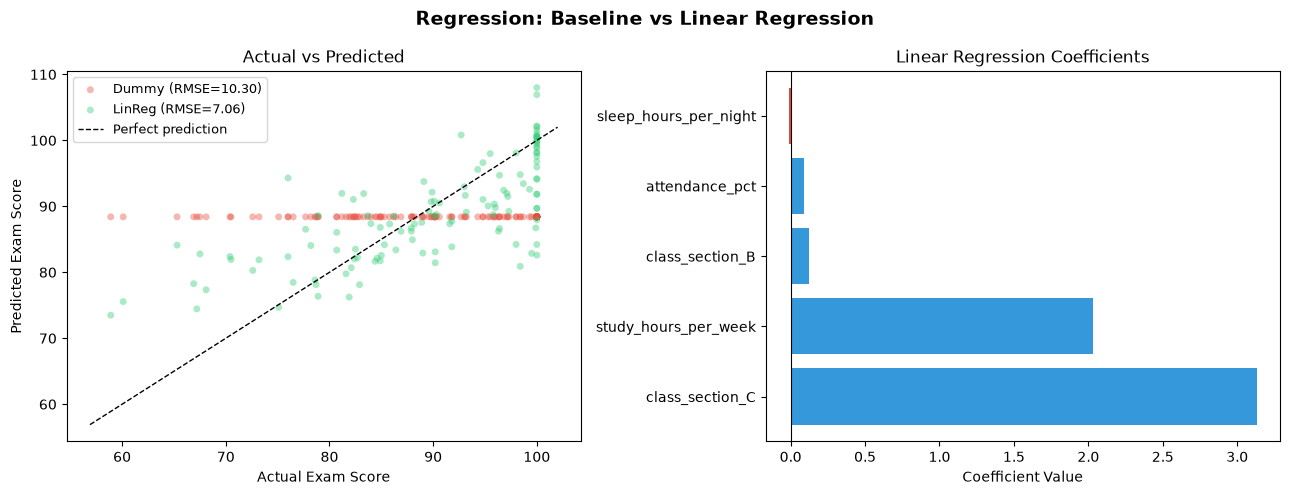

Saved: regression_results.png


In [17]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle("Regression: Baseline vs Linear Regression", fontsize=14, fontweight="bold")

# --- Left: Actual vs Predicted scatter ---
ax = axes[0]
ax.scatter(y_test_reg, y_pred_dummy_reg, alpha=0.4, color="#e74c3c",
           label=f"Dummy (RMSE={dummy_rmse:.2f})", s=25, edgecolors="none")
ax.scatter(y_test_reg, y_pred_lin, alpha=0.4, color="#2ecc71",
           label=f"LinReg (RMSE={lin_rmse:.2f})", s=25, edgecolors="none")
lims = [y_test_reg.min() - 2, y_test_reg.max() + 2]
ax.plot(lims, lims, "k--", lw=1, label="Perfect prediction")
ax.set_xlabel("Actual Exam Score")
ax.set_ylabel("Predicted Exam Score")
ax.set_title("Actual vs Predicted")
ax.legend(fontsize=9)

# --- Right: Coefficients bar chart ---
ax2 = axes[1]
colors = ["#3498db" if c > 0 else "#e74c3c" for c in coef_df["Coefficient"]]
ax2.barh(coef_df["Feature"], coef_df["Coefficient"], color=colors)
ax2.axvline(0, color="black", linewidth=0.8)
ax2.set_xlabel("Coefficient Value")
ax2.set_title("Linear Regression Coefficients")

plt.tight_layout()
plt.savefig("Graph/regression_results.png", dpi=130, bbox_inches="tight")
plt.show()
print("Saved: regression_results.png")

## 8. Build the classification target — `distinction`
**Task:** Predict whether a student earned a **distinction** (exam_score ≥ 85).
We add a `distinction` column: 1 = distinction, 0 = no distinction.
>if `exam_score >= 85`, else `0`. The fraction of students hitting this threshold
tells us whether the classes are balanced, which we need to correctly interpret
accuracy in the next step.

In [18]:
features_df["distinction"] = (features_df["exam_score"] >= 85).astype(int)

y_clf = features_df["distinction"]

distinction_rate = y_clf.mean()
print(f"Distinction rate : {distinction_rate:.2%} of students scored ≥ 85")
print(f"  Class 1 (distinction)    : {y_clf.sum()} students")
print(f"  Class 0 (no distinction) : {(y_clf == 0).sum()} students")
print(
    f"\n  This {distinction_rate:.0%} rate means the majority class is "
    f"{'distinction' if distinction_rate > 0.5 else 'no-distinction'}."
    f" A baseline that always predicts the majority class will score "
    f"~{max(distinction_rate, 1-distinction_rate):.0%} accuracy "
    f"while having learned nothing at all."
)

Distinction rate : 65.33% of students scored ≥ 85
  Class 1 (distinction)    : 392 students
  Class 0 (no distinction) : 208 students

  This 65% rate means the majority class is distinction. A baseline that always predicts the majority class will score ~65% accuracy while having learned nothing at all.


---
## 9. Classification — Train / Test Split (stratified)

`stratify=y_clf` ensures the same class proportion is preserved in both
train and test halves, critical for imbalanced targets so the test set
doesn't accidentally contain only one class.

In [19]:
X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X, y_clf, test_size=0.2, random_state=RANDOM_STATE, stratify=y_clf
)

print(f"Train set: {X_train_c.shape[0]} rows | distinction rate = {y_train_c.mean():.2%}")
print(f"Test set : {X_test_c.shape[0]} rows | distinction rate = {y_test_c.mean():.2%}")

Train set: 480 rows | distinction rate = 65.42%
Test set : 120 rows | distinction rate = 65.00%


---
## 10. Classification — Part A: Dummy Baseline

`DummyClassifier(strategy="most_frequent")` always predicts the majority
class, regardless of features. If distinction students are the minority (or
majority) of the dataset, this baseline can still score deceptively high on
**accuracy** while having learned nothing at all which is exactly why we also
compute precision, recall, and F1.

In [20]:
dummy_clf = DummyClassifier(strategy="most_frequent", random_state=RANDOM_STATE)
dummy_clf.fit(X_train_c, y_train_c)

y_pred_dummy_clf = dummy_clf.predict(X_test_c)

d_acc  = accuracy_score (y_test_c, y_pred_dummy_clf)
d_prec = precision_score(y_test_c, y_pred_dummy_clf, zero_division=0)
d_rec  = recall_score   (y_test_c, y_pred_dummy_clf, zero_division=0)
d_f1   = f1_score       (y_test_c, y_pred_dummy_clf, zero_division=0)

print("=== Classification Baseline (DummyClassifier — most_frequent) ===")
print(f"  Accuracy  : {d_acc:.4f}")
print(f"  Precision : {d_prec:.4f}")
print(f"  Recall    : {d_rec:.4f}")
print(f"  F1 Score  : {d_f1:.4f}")
print(
    f"\n  One-sentence on accuracy: The baseline scores {d_acc:.0%} accuracy "
    f"simply by predicting the majority class every time — this number is "
    f"misleading because it reflects class imbalance, not any learned pattern; "
    f"its F1 of {d_f1:.2f} (The baseline predicts every student as distinction, so it achieves {d_rec:.2f} i.e 100% recall for distinction but 0% recall for students without distinction.) "
    f"expose that the 'model' catches nothing useful."
)

=== Classification Baseline (DummyClassifier — most_frequent) ===
  Accuracy  : 0.6500
  Precision : 0.6500
  Recall    : 1.0000
  F1 Score  : 0.7879

  One-sentence on accuracy: The baseline scores 65% accuracy simply by predicting the majority class every time — this number is misleading because it reflects class imbalance, not any learned pattern; its F1 of 0.79 (The baseline predicts every student as distinction, so it achieves 1.00 i.e 100% recall for distinction but 0% recall for students without distinction.) expose that the 'model' catches nothing useful.


---
## 11. Classification — Part B: Logistic Regression


In [21]:
log_reg = LogisticRegression(random_state=RANDOM_STATE, max_iter=1000)
log_reg.fit(X_train_c, y_train_c)

y_pred_log = log_reg.predict(X_test_c)

l_acc  = accuracy_score (y_test_c, y_pred_log)
l_prec = precision_score(y_test_c, y_pred_log, zero_division=0)
l_rec  = recall_score   (y_test_c, y_pred_log, zero_division=0)
l_f1   = f1_score       (y_test_c, y_pred_log, zero_division=0)

print("=== Logistic Regression ===")
print(f"  Accuracy  : {l_acc:.4f}")
print(f"  Precision : {l_prec:.4f}")
print(f"  Recall    : {l_rec:.4f}")
print(f"  F1 Score  : {l_f1:.4f}")
print("\n--- Full Classification Report ---")
print(classification_report(y_test_c, y_pred_log,
                             target_names=["No Distinction", "Distinction"]))

print(
    f"\n  One-sentence comparison: Logistic Regression raised F1 from "
    f"{d_f1:.2f} to {l_f1:.2f} (+{l_f1-d_f1:.2f}), precision from "
    f"{d_prec:.2f} to {l_prec:.2f}, and recall from {d_rec:.2f} to "
    f"{l_rec:.2f}, unlike the baseline which predicted only the majority "
    f"class, the real model actually identifies distinction students with "
    f"meaningful recall, demonstrating genuine generalisation."
)

=== Logistic Regression ===
  Accuracy  : 0.7667
  Precision : 0.8125
  Recall    : 0.8333
  F1 Score  : 0.8228

--- Full Classification Report ---
                precision    recall  f1-score   support

No Distinction       0.68      0.64      0.66        42
   Distinction       0.81      0.83      0.82        78

      accuracy                           0.77       120
     macro avg       0.74      0.74      0.74       120
  weighted avg       0.76      0.77      0.77       120


  One-sentence comparison: Logistic Regression raised F1 from 0.79 to 0.82 (+0.03), precision from 0.65 to 0.81, and recall from 1.00 to 0.83, unlike the baseline which predicted only the majority class, the real model actually identifies distinction students with meaningful recall, demonstrating genuine generalisation.


## Classification Visualisation

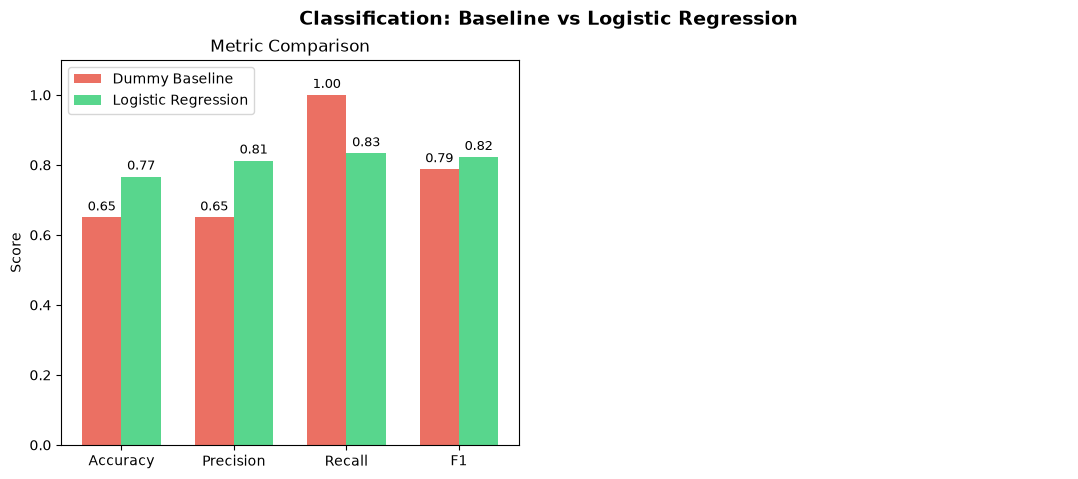

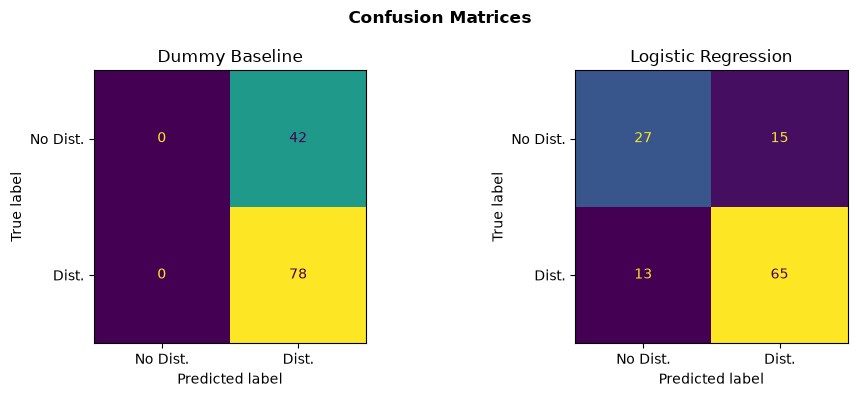

Saved: classification_metrics.png  |  confusion_matrices.png


In [22]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle("Classification: Baseline vs Logistic Regression", fontsize=14, fontweight="bold")

# --- Left: Metrics bar chart ---
ax = axes[0]
metrics  = ["Accuracy", "Precision", "Recall", "F1"]
baseline = [d_acc, d_prec, d_rec, d_f1]
logreg   = [l_acc, l_prec, l_rec, l_f1]

x = np.arange(len(metrics))
w = 0.35
ax.bar(x - w/2, baseline, w, label="Dummy Baseline", color="#e74c3c", alpha=0.8)
ax.bar(x + w/2, logreg,   w, label="Logistic Regression", color="#2ecc71", alpha=0.8)
ax.set_xticks(x)
ax.set_xticklabels(metrics)
ax.set_ylim(0, 1.1)
ax.set_ylabel("Score")
ax.set_title("Metric Comparison")
ax.legend()
for i, (b, l) in enumerate(zip(baseline, logreg)):
    ax.text(i - w/2, b + 0.02, f"{b:.2f}", ha="center", fontsize=9)
    ax.text(i + w/2, l + 0.02, f"{l:.2f}", ha="center", fontsize=9)

# --- Right: Confusion matrices side by side ---
ax2 = axes[1]
ax2.axis("off")

fig2, cm_axes = plt.subplots(1, 2, figsize=(10, 4))
for ax_cm, preds, title in zip(
    cm_axes,
    [y_pred_dummy_clf, y_pred_log],
    ["Dummy Baseline", "Logistic Regression"]
):
    ConfusionMatrixDisplay.from_predictions(
        y_test_c, preds,
        display_labels=["No Dist.", "Dist."],
        ax=ax_cm, colorbar=False
    )
    ax_cm.set_title(title)
fig2.suptitle("Confusion Matrices", fontweight="bold")
fig2.tight_layout()
fig2.savefig("Graph/confusion_matrices.png", dpi=130, bbox_inches="tight")
plt.show()

fig.tight_layout()
fig.savefig("Graph/classification_metrics.png", dpi=130, bbox_inches="tight")
plt.show()
print("Saved: classification_metrics.png  |  confusion_matrices.png")

---
## 12. Final Summary Table

In [23]:
summary = pd.DataFrame({
    "Model"    : ["Dummy Regressor", "Linear Regression",
                  "Dummy Classifier", "Logistic Regression"],
    "Task"     : ["Regression", "Regression", "Classification", "Classification"],
    "RMSE"     : [f"{dummy_rmse:.4f}", f"{lin_rmse:.4f}", "—", "—"],
    "R²"       : [f"{dummy_r2:.4f}", f"{lin_r2:.4f}", "—", "—"],
    "Accuracy" : ["—", "—", f"{d_acc:.4f}", f"{l_acc:.4f}"],
    "Precision": ["—", "—", f"{d_prec:.4f}", f"{l_prec:.4f}"],
    "Recall"   : ["—", "—", f"{d_rec:.4f}", f"{l_rec:.4f}"],
    "F1"       : ["—", "—", f"{d_f1:.4f}", f"{l_f1:.4f}"],
})

print("=== COMPLETE PIPELINE SUMMARY ===")
print(summary.to_string(index=False))

=== COMPLETE PIPELINE SUMMARY ===
              Model           Task    RMSE      R² Accuracy Precision Recall     F1
    Dummy Regressor     Regression 10.2978 -0.0096        —         —      —      —
  Linear Regression     Regression  7.0584  0.5257        —         —      —      —
   Dummy Classifier Classification       —       —   0.6500    0.6500 1.0000 0.7879
Logistic Regression Classification       —       —   0.7667    0.8125 0.8333 0.8228


---
## 13. Reproducibility Verification

**This notebook runs top-to-bottom with Restart Kernel → Run All.**

Every source of randomness is fixed:
- `np.random.seed(42)` at top
- `train_test_split(..., random_state=42)` for both splits
- `LogisticRegression(random_state=42)`
- `DummyClassifier(random_state=42)`

No manual reordering is required. All outputs are deterministic.

In [24]:
print("✅ ML pipeline completed.")
print(f"   Regression  → RMSE: {lin_rmse:.4f}, R²: {lin_r2:.4f}")
print(f"   Classification → Accuracy: {l_acc:.4f}, F1: {l_f1:.4f}")
print("\nBoth real models beat their respective baselines. Pipeline is reproducible.")

✅ ML pipeline completed.
   Regression  → RMSE: 7.0584, R²: 0.5257
   Classification → Accuracy: 0.7667, F1: 0.8228

Both real models beat their respective baselines. Pipeline is reproducible.
